In [11]:
import pandas as pd
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt
import os
from pathlib import Path
import seaborn as sns
from scipy.stats import wasserstein_distance
from matplotlib.pyplot import tight_layout

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance

label_dict  = {}
label_dict['huber_value'] = r"Huber $\mathcal{H}$"
label_dict['stem_hydraulic_capacitance'] = r"$\Gamma_\mathrm{sap, max}$"
label_dict['stem_hydraulic_capacitance_res'] = r"$\Gamma_\mathrm{sap,res}$"
label_dict['leaf_hydraulic_capacitance'] = r"$\Gamma_\mathrm{Leaf}$"
label_dict['g0'] = r"$g_0$"
label_dict['g1'] = r"$g_1$"
label_dict['k_xylem_sat'] = r"$K_\mathrm{xyl, max}$"
label_dict['psi50_xylem'] = r"$\psi_{50}$"
label_dict['psi88_xylem'] = r"$\psi_{88}$"
label_dict['wcont_sigma_deviation'] = r"$\sigma_\mathrm{wcont}$"
label_dict['pore_0'] = r"$\xi$"
label_dict['jackson_root_beta'] = r"$\mathrm{Root}_\beta$"
label_dict['psi_leaf_50_close'] = r"$\psi_{Leaf, close}$"
label_dict['d_50_close'] = r"$d_{Leaf, close}$"
label_dict['alpha'] = r"$\alpha$"
label_dict['gam_stem_x_H'] = r"$\Gamma_\mathrm{Stem} \cdot \mathcal{H}$"
label_dict['gam_stem_div_g0'] = r"$\frac{g_0}{\Gamma_\mathrm{Stem}}$"
label_dict['k_xyl_x_H'] = r"$K_\mathrm{xyl, max}\cdot \mathcal{H}$"

label_dict['g_stem_res'] = r"$g_\mathrm{stem,res}$"
label_dict['g_min_loss'] = r"$g_0 + g_\mathrm{Bark}$"
label_dict['wcont_sigma_deviation'] = r"$\sigma_\mathrm{wcont}$"
label_dict['p50-p88'] =  r"$\psi_{50} - \psi_{88} $"
label_dict['g0_div_gam_stem_x_H'] =  r"g0_div_gam_stem_x_H"
label_dict['g0_div_gam_stem_x_H'] =  r"g0_div_gam_stem_x_H"
label_dict['k_soil_sat0'] =  r"k_soil_sat"
label_dict['root_area_index'] =  r"RAI"
label_dict['psi_tlp'] = r'$\psi_\mathrm{sap, tlp}$'



unit_dict= {}
unit_dict['stem_hydraulic_capacitance'] = "kg m-3 MPa-1"
unit_dict['stem_hydraulic_capacitance_res'] = "kg m-3 MPa-1"
unit_dict['leaf_hydraulic_capacitance'] = "kg m-2 MPa-1"
unit_dict['k_xylem_sat'] = "kg m-1 s-1 MPa-1"
unit_dict['huber_value'] = "cm2 m-2"
unit_dict['psi50_xylem'] = "MPa"
unit_dict['psi88_xylem'] = "MPa"
unit_dict['g0'] = "mol m-1 s-1"
unit_dict['g1'] = "-"
unit_dict['g_stem_res'] = "mol m-1 s-1"
unit_dict['psi_leaf_50_close'] = r"MPa"
unit_dict['d_50_close'] = "-"
unit_dict['alpha'] = r"-"
unit_dict['gam_stem_x_H'] = r"-"
unit_dict['gam_stem_div_g0'] = r"-"
unit_dict['k_xyl_x_H'] =r"-"
unit_dict['g_min_loss'] = r"-"
unit_dict['wcont_sigma_deviation'] = r"-"
unit_dict['p50-p88'] =  "MPa"
unit_dict['psi_tlp'] =  "MPa"
unit_dict['g0_div_gam_stem_x_H'] =  "-"
unit_dict['pore_0'] =  "-"
unit_dict['k_soil_sat0'] =  "m s-1"
unit_dict['root_area_index'] =  "m2 m-2"


root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem"
scenario_name = "big_overview_20_10000p"

root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_2024_final"
scenario_name = "big_overview_20_10000p_fine_g1fix_relay"

root_output_directory = "/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/"
scenario_name = "45_LHS_TLP"


root_output_directory = "/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/"
scenario_name = "45_LHS_TLP"
scenario_name = "45-3_LHS_no_gstem_full"
nmax = 1000
#scenario_name = "23_ex_con_2025_full_logit_mean_one_wcont"

input_path = os.path.join(root_output_directory, scenario_name, 'input')
output_path = os.path.join(root_output_directory, scenario_name, 'output')
post_path = os.path.join(root_output_directory, scenario_name, 'post')
vars_all = ['psi_leaf_50_close', 'd_50_close', 'stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value',
        'leaf_hydraulic_capacitance', 'psi50_xylem', 'psi88_xylem', 'g0', 'k_soil_sat0', 'psi_soil_sat0', 'jackson_root_beta',
        'pore_0', 'root_area_index', 'wcont_sigma_deviation', 'alpha', 'g_stem_res','gam_stem_x_H','k_xyl_x_H', 
        'g0_div_gam_stem_x_H', 'p50-p88', 'g1', 'psi_tlp']

vars_all.append('stem_hydraulic_capacitance_res')

vars_plant = ['stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value', 'leaf_hydraulic_capacitance', 'psi50_xylem',
              'g0','psi_leaf_50_close', 'd_50_close', 'alpha','psi88_xylem']

vars_plant_ex = ['stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value', 'leaf_hydraulic_capacitance', 'psi50_xylem',
              'g0','psi_leaf_50_close', 'd_50_close', 'alpha','psi88_xylem', 'gam_stem_x_H','k_xyl_x_H', 'g0_div_gam_stem_x_H', 'g_min_loss']
vars_all_ex = vars_all.copy()
vars_all_ex.append("RMSE_MAX")

df = pd.read_csv(os.path.join(post_path, f"All_RMSE_{nmax}.csv"))
df['stem_hydraulic_capacitance'] *= 18.0/1000.0
df['stem_hydraulic_capacitance_res'] *= 18.0/1000.0
df['huber_value'] *= 10000.0
df['k_xylem_sat'] *= 18.0/1000.0
df['alpha'] = df['g_stem_res']/ df['g0']
df['gam_stem_x_H'] = df['stem_hydraulic_capacitance'] * df['huber_value']
df['k_xyl_x_H'] = df['k_xylem_sat'] * df['huber_value']
df['g0_div_gam_stem_x_H'] =  df['g0']/df['stem_hydraulic_capacitance']* df['huber_value']
#df['g_min_loss'] = df['g0'] + df['g_stem_res']
df['p50-p88'] = df['psi50_xylem'] - df['psi88_xylem']


df.loc[df['sid'] ==0, 'sid'] =1 
df.loc[df['sid'] ==-1, 'sid'] =0 
df.loc[df['sid'] ==3, 'sid'] =2 
df.loc[df['sid'] ==6, 'sid'] =3 
df.loc[df['sid'] ==7, 'sid'] =4 

index_to_drop = df[(df['sid']==2)|(df['sid']==2)].index
df.drop(index_to_drop, inplace=True)

dv = df[vars_all]
dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])
df_norm = dv
df_norm['sid'] = df['sid']

df_norm.shape



df_norm['alive'] = 1
df_norm.loc[df_norm['sid'] > 0, 'alive'] = 0

df_norm["sid_group"] = df_norm["sid"].apply(lambda s: "sid 0" if s == 0 else "other")
palette = {"sid 0": "tab:blue", "other": "tab:red"}

/tmp/ipykernel_1481151/4031729856.py:132: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])
/tmp/ipykernel_1481151/4031729856.py:134: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_norm['sid'] = df['sid']
/tmp/ipykernel_1481151/4031729856.py:140: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: ht

In [12]:
import numpy as np
import pandas as pd
from scipy.stats import iqr, wasserstein_distance

# --- returns (W_raw, W_std) ---
def standardized_wasserstein(x, y, scale="iqr", eps=1e-12):
    x = np.asarray(pd.Series(x).dropna(), dtype=float)
    y = np.asarray(pd.Series(y).dropna(), dtype=float)
    if x.size == 0 or y.size == 0:
        return np.nan, np.nan
    W = wasserstein_distance(x, y)
    pooled = np.concatenate([x, y])
    s = iqr(pooled, nan_policy="omit") if scale == "iqr" else np.nanstd(pooled, ddof=1)
    return W, W / max(s, eps)

def wasserstein_vs_ref_table(df, value_col, group_col="sid", ref_sid=0, scale="iqr"):
    """Per-sid raw and standardized Wasserstein vs reference."""
    ref_vals = df.loc[df[group_col] == ref_sid, value_col].astype(float).dropna().values
    rows = []
    for g, sub in df.groupby(group_col, sort=True):
        vals = sub[value_col].astype(float).dropna().values
        W, W_std = standardized_wasserstein(ref_vals, vals, scale=scale)
        rows.append({group_col: g, "W_raw": W, "W_std": W_std})
    return pd.DataFrame(rows).sort_values(group_col).reset_index(drop=True)

def avg_wstd_across_sids(df, variables, group_col="sid", ref_sid=0, scale="iqr",
                         alive_col="alive"):
    """
    For each variable, average W_std across all non-reference sids and
    add mean values split by alive/dead.
    Returns columns:
    ['variable','avg_W_std','n_sids','avg_W_raw',
     'mean_alive','n_alive','mean_dead','n_dead','delta_mean']
    """
    if isinstance(variables, str):
        variables = [variables]

    # make a safe boolean mask for alive/dead if column exists
    has_alive = alive_col in df.columns
    if has_alive:
        alive_mask = df[alive_col].astype(float) > 0
    out = []

    for v in variables:
        # average standardized Wasserstein vs ref across sids
        res = wasserstein_vs_ref_table(df, v, group_col=group_col, ref_sid=ref_sid, scale=scale)
        nonref = res[res[group_col] != ref_sid]

        # alive/dead means
        if has_alive:
            vals_alive = pd.to_numeric(df.loc[alive_mask, v], errors="coerce")
            vals_dead  = pd.to_numeric(df.loc[~alive_mask, v], errors="coerce")
            mean_alive = vals_alive.mean()
            mean_dead  = vals_dead.mean()
            n_alive    = vals_alive.notna().sum()
            n_dead     = vals_dead.notna().sum()
        else:
            mean_alive = mean_dead = np.nan
            n_alive = n_dead = 0

        out.append({
            "variable": v,
            "avg_W_std": nonref["W_std"].mean(),
            "n_sids": int(nonref["W_std"].notna().sum()),
            "avg_W_raw": nonref["W_raw"].mean(),
            "mean_alive": mean_alive,
            "n_alive": int(n_alive),
            "mean_dead": mean_dead,
            "n_dead": int(n_dead),
            "delta_mean": (mean_alive - mean_dead) if has_alive else np.nan
        })

    return pd.DataFrame(out).sort_values("avg_W_std", ascending=False).reset_index(drop=True)


In [13]:
# Multiple variables
vars_to_compare = [
    "stem_hydraulic_capacitance", "g0"
    # add more variables here, e.g. "xylem_conductivity", "leaf_area_index"
]
vars_to_compare = ['psi_leaf_50_close',
 #'d_50_close',
 'stem_hydraulic_capacitance',
 'stem_hydraulic_capacitance_res',
 'k_xylem_sat',
 'huber_value',
 'leaf_hydraulic_capacitance',
 #'psi50_xylem',
 'psi88_xylem',
 'p50-p88',
 'g0',
 'root_area_index',
 'wcont_sigma_deviation',
 'alpha',
 'g_stem_res',
 #'#gam_stem_x_H',
 #'k_xyl_x_H',
 #'g0_div_gam_stem_x_H',
 #'g_min_loss', 
 'g1','k_soil_sat0',
 #'psi_soil_sat0', 
 #'pore_0', 
 'psi_tlp' ]

['k_soil_sat0',
 'psi_soil_sat0', 'pore_0',]


table_many = avg_wstd_across_sids(
    df_norm, variables=vars_to_compare, group_col="sid", ref_sid=0, scale="iqr"
)

In [14]:
np.round(table_many[['variable', 'avg_W_std', 'mean_alive', 'mean_dead']], 5)

,variable,avg_W_std,mean_alive,mean_dead
0,wcont_sigma_deviation,1.03075,1.89580,0.38867
1,psi88_xylem,0.84067,-4.59411,-4.38805
2,psi_leaf_50_close,0.82696,-1.12502,-0.92834
3,p50-p88,0.67397,0.76829,0.62516
4,k_xylem_sat,0.63044,1.10953,1.41051
5,huber_value,0.41723,5.06537,5.34390
6,stem_hydraulic_capacitance,0.37094,173.74929,174.83802
7,psi_tlp,0.33321,-2.15846,-2.25959
8,stem_hydraulic_capacitance_res,0.27909,19.93912,22.46942
9,g1,0.17256,2.31672,2.23435


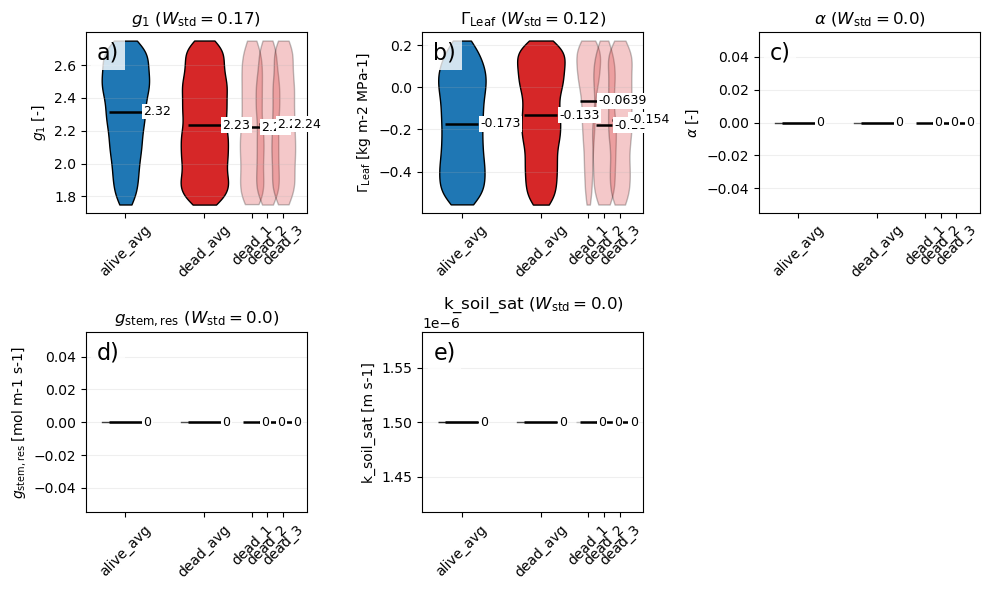

Saved figure to: /Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/45-3_LHS_no_gstem_full/post/Fig2_Wasserstein_1000_si.png


In [15]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- config ---
W_MAIN  = 0.60
W_INDIV = 0.30
# dead trees are sid 1, 3, 4
CLUSTER_X = {1: 1.6, 3: 1.8, 4: 2.0}  # only three dead trees

def _shift_new_polys(ax, before, dx, color=None, alpha=1.0):
    """Shift newly added violin polygons horizontally by dx."""
    new_poly = [c for c in ax.collections if c not in before]
    for pc in new_poly:
        for path in pc.get_paths():
            v = path.vertices
            v[:, 0] += dx
        if color is not None:
            pc.set_facecolor(color)
            pc.set_edgecolor("black")
            pc.set_alpha(alpha)

def _fmt_2sig(x):
    """Format number to 2 significant digits; return '' if nan."""
    if x is None or not np.isfinite(x):
        return ""
    s = f"{x:.3g}"
    # If scientific notation, switch to fixed-point with trimming
    if "e" in s or "E" in s:
        s = f"{float(s):.3f}".rstrip("0").rstrip(".")
    return s

def _draw_mean_line(ax, x_center, width, y_mean, label=None):
    """Draw a short horizontal mean line at y_mean centered on x_center, add text."""
    if not np.isfinite(y_mean):
        return
    half = width * 0.35  # a little shorter than violin width
    x0, x1 = x_center - half, x_center + half
    ax.hlines(y_mean, x0, x1, linewidth=1.8, color="black")
    if label:
        # place label slightly to the right of the line, with a small vertical offset
        ax.text(x1 + 0.02, y_mean, label, va="center", ha="left", fontsize=9, color="black",
                   bbox=dict(facecolor="white", edgecolor="none", pad=1.0)
        )

def plot_one_violin_panel(ax, df_norm, var):
    df_plot = df_norm.copy()
    df_plot.loc[df_plot["sid"] == 0, "sid_label"] = "0"
    df_plot.loc[df_plot["sid"].isin([1, 3, 4]), "sid_label"] = "avg"

    # --- avg_alive (sid=0, blue) ---
    before = set(ax.collections)
    sns.violinplot(
        data=df_plot[df_plot["sid_label"] == "0"],
        x="sid_label", y=var,
        order=["0", "avg", "c1", "c3", "c4"],
        cut=0, linewidth=1, width=W_MAIN, inner=None, ax=ax
    )
    _shift_new_polys(ax, before, dx=0, color="tab:blue", alpha=1.0)

    # --- avg_dead (pooled 1,3,4, red) ---
    before = set(ax.collections)
    sns.violinplot(
        data=df_plot[df_plot["sid_label"] == "avg"],
        x="sid_label", y=var,
        order=["0", "avg", "c1", "c3", "c4"],
        cut=0, linewidth=1, width=W_MAIN, inner=None, ax=ax
    )
    _shift_new_polys(ax, before, dx=0, color="tab:red", alpha=1.0)

    # --- indiv_dead (1,3,4, transparent red, clustered) ---
    for sid, cat in zip([1, 3, 4], ["c1", "c3", "c4"]):
        di = df_norm.loc[df_norm["sid"] == sid, [var]].copy()
        if di.empty:
            continue
        di["sid_label"] = cat
        before = set(ax.collections)
        sns.violinplot(
            data=di, x="sid_label", y=var,
            order=["0", "avg", "c1", "c3", "c4"],
            cut=0, linewidth=1, width=W_INDIV, inner=None, ax=ax
        )
        base_pos = {"c1": 2.0, "c3": 3.0, "c4": 4.0}[cat]
        _shift_new_polys(ax, before, dx=CLUSTER_X[sid]-base_pos,
                         color="tab:red", alpha=0.25)

    # --- ticks & cosmetics ---
    cluster_positions = list(CLUSTER_X.values())
    
    
    cluster_labels = [f"dead_{sid}" for sid in [1,2,3]]

    ax.set_xticks([0, 1, *cluster_positions])
    ax.set_xticklabels(["alive_avg", "dead_avg", *cluster_labels], rotation=45)

    ax.set_xlim(-0.5, max(CLUSTER_X.values()) + 0.3)
    
    
    

    # --- draw mean lines + labels (2 sig figs) ---
    # alive avg at x=0
    mean_alive = np.nanmean(df_plot.loc[df_plot["sid_label"] == "0", var])
    _draw_mean_line(ax, x_center=0, width=W_MAIN, y_mean=mean_alive, label=_fmt_2sig(mean_alive))

    # dead pooled avg at x=1
    mean_dead = np.nanmean(df_plot.loc[df_plot["sid_label"] == "avg", var])
    _draw_mean_line(ax, x_center=1, width=W_MAIN, y_mean=mean_dead, label=_fmt_2sig(mean_dead))

    # individual dead at x=CLUSTER_X[sid]
    for sid in [1, 3, 4]:
        m = np.nanmean(df_norm.loc[df_norm["sid"] == sid, var])
        _draw_mean_line(ax, x_center=CLUSTER_X[sid], width=W_INDIV, y_mean=m, label=_fmt_2sig(m))

    # --- title etc. ---
    w_qid = table_many.loc[table_many['variable'] == var, 'avg_W_std']
    w_qid = np.round(w_qid, 2)
    wasser_str = f'$W_{{\\mathrm{{std}}}} = {w_qid.values[0]}$'

    ax.set_title(rf"{label_dict[var]} ({wasser_str})")
    ax.set_xlabel("")
    ax.set_ylabel(f"{label_dict[var]} [{unit_dict[var]}]")
    ax.grid(axis="y", alpha=0.2)
    ax.legend([], [], frameon=False)

# --------- make a 3x3 grid over the last 3 variables ---------
vars_to_plot = table_many['variable'][[9, 10, 13, 14, 15]]

fig, axes = plt.subplots(2, 3, figsize=(10, 6), sharey=False)
axes = axes.flatten()

i = 1
labels = ['a)' , 'b)', 'c)', 'd)', 'e)', 'f)', 'g)', 'h)', 'i)']

for ax, var in zip(axes, vars_to_plot):
    plot_one_violin_panel(ax, df_norm, var)
    
    ax.text(
        0.05, 0.95, labels[i-1],          # X=5%, Y=95% of axes
        transform=ax.transAxes,
        fontsize=16,
        va='top', ha='left',              # Align to top-left
        bbox=dict(
            facecolor='white',            # white background
            edgecolor='none',            # thin black border (or 'none' to remove)
            #boxstyle='round,pad=0.3',     # rounded corners, small padding
            alpha=0.8                     # slight transparency (adjust 0–1)
        )
    )
    i += 1

# hide any unused subplots (if fewer than 9 vars)
for ax in axes[len(vars_to_plot):]:
    ax.axis("off")

plt.tight_layout()
out_path = os.path.join(post_path, f"Fig2_Wasserstein_{nmax}_si.png")
plt.savefig(out_path, dpi=200)
plt.show()
print(f"Saved figure to: {out_path}")
